# 04 · Modeling — Linear Regression (baseline) + XGBoost
**Data Science Diploma · ENES UNAM León**

### Evaluation Strategy for Time Series

> **Important:** In time series **random `train_test_split` is NOT used**. We always split chronologically:

```
|------- Train (70%) -------|-- Val (15%) --|-- Test (15%) --|
2024-01                  ~Oct 2024       ~Dec 2024       2025-03
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Base paths
RAW_DIR       = os.path.join(os.getcwd(), 'data', 'raw')
PROCESSED_DIR = os.path.join(os.getcwd(), 'data', 'processed')
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Load dataset with features
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'sol_usd_features.csv'), index_col=0, parse_dates=True)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f'Dataset loaded: {df.shape}')
df.head(3)

Dataset loaded: (422, 39)


,Close,High,Low,Open,Volume,daily_return,volatility_21d,return_lag_1,return_lag_2,return_lag_3,...,BB_upper,BB_lower,BB_width,BB_position,Volume_change,Volume_SMA7,Volume_ratio,day_of_week,month,Target
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-22,257.237366,271.530029,248.751602,250.413788,8880832578,2.724921,5.885205,3.369887,-3.326652,-4.308778,...,265.980809,162.508084,0.482966,0.915500,-16.961232,1.569195e+10,0.565948,2,1,-1.470302
2025-01-23,253.455200,258.129150,242.496185,257.236237,9264528949,-1.470302,5.770995,2.724921,3.369887,-3.326652,...,270.658835,161.400845,0.505754,0.842541,4.320500,1.614415e+10,0.573863,3,1,-0.037079
2025-01-24,253.361221,269.805786,247.631470,253.455200,7483041553,-0.037079,5.712077,-1.470302,2.724921,3.369887,...,274.993298,160.740212,0.524417,0.810665,-19.229120,1.648198e+10,0.454013,4,1,1.070549


## 4.1 Define Features and Target

In [2]:
FEATURE_COLS = [
    'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'return_lag_7', 'return_lag_14',
    'Close_to_SMA7', 'Close_to_SMA21', 'Close_to_EMA12', 'Close_to_EMA26',
    'RSI_14', 'MACD_pct', 'MACD_signal_pct',
    'BB_width', 'BB_position', 'volatility_21d',
    'Volume_change', 'Volume_ratio',
    'day_of_week', 'month'
]
TARGET = 'Target'

X = df[FEATURE_COLS]
y = df[TARGET]

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]}')
print(f'Target   : next-day return (%)')

Features : 20
Samples  : 422
Target   : next-day return (%)


## 4.2 Chronological Split (No Data Leakage)

Train : 295 samples | 2025-01-22 → 2025-11-12
Val   : 63   samples | 2025-11-13   → 2026-01-14
Test  : 64  samples | 2026-01-15  → 2026-03-19


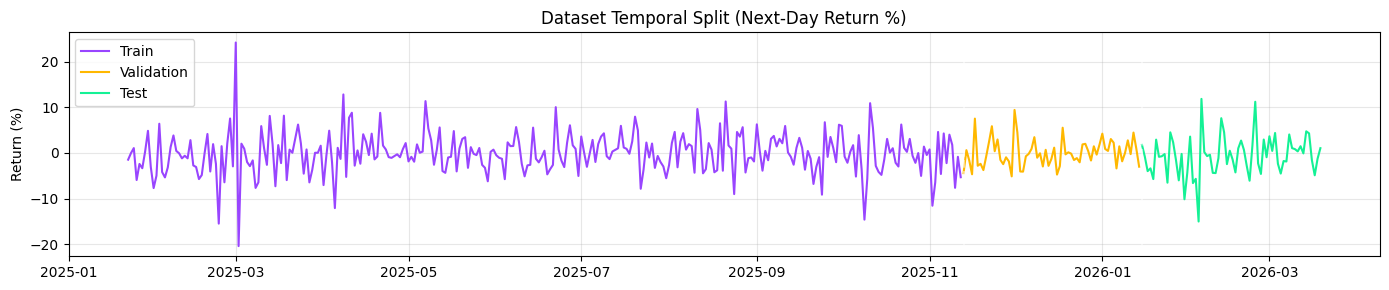

In [3]:
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X.iloc[:train_end],  y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:],    y.iloc[val_end:]

dates_train = df.index[:train_end]
dates_val   = df.index[train_end:val_end]
dates_test  = df.index[val_end:]

# Close prices needed for price reconstruction later
close_val  = df['Close'].iloc[train_end:val_end].values
close_test = df['Close'].iloc[val_end:].values

print(f'Train : {len(X_train)} samples | {dates_train[0].date()} → {dates_train[-1].date()}')
print(f'Val   : {len(X_val)}   samples | {dates_val[0].date()}   → {dates_val[-1].date()}')
print(f'Test  : {len(X_test)}  samples | {dates_test[0].date()}  → {dates_test[-1].date()}')

# Actual next-day prices (for evaluation after reconstruction)
real_price_val  = close_val  * (1 + y_val.values  / 100)
real_price_test = close_test * (1 + y_test.values / 100)

# Visualize the split (returns, %)
plt.figure(figsize=(14, 3))
plt.plot(dates_train, y_train, label='Train', color='#9945FF', linewidth=1.5)
plt.plot(dates_val,   y_val,   label='Validation', color='#FFB800', linewidth=1.5)
plt.plot(dates_test,  y_test,  label='Test', color='#14F195', linewidth=1.5)
plt.axvline(dates_val[0],  color='white', linestyle='--', alpha=0.5)
plt.axvline(dates_test[0], color='white', linestyle='--', alpha=0.5)
plt.title('Dataset Temporal Split (Next-Day Return %)')
plt.ylabel('Return (%)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, '04_split.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4.3 Normalization

Linear regression requires features to be on the same scale. XGBoost does not require it, but applying it does no harm.

In [4]:
scaler = StandardScaler()

# IMPORTANT: fit only on train, transform on val and test
# This prevents data leakage during normalization
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Normalization applied')
print(f'Feature mean (train): {X_train_sc.mean(axis=0).mean():.6f} (≈0 expected)')
print(f'Std dev (train)      : {X_train_sc.std(axis=0).mean():.4f} (≈1 expected)')

Normalization applied
Feature mean (train): 0.000000 (≈0 expected)
Std dev (train)      : 1.0000 (≈1 expected)


## 4.4 Metrics Function

In [5]:
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f'\n **{name}**')
    print(f'  MAE  = ${mae:.2f}   (average absolute error)')
    print(f'  RMSE = ${rmse:.2f}  (penalizes large errors)')
    print(f'  MAPE = {mape:.2f}%  (average percentage error)')
    print(f'  R²   = {r2:.4f}    (1.0 = perfect)')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

results = []

## 4.5 Model 1: Linear Regression (Baseline)

The baseline is the minimum reference point. If XGBoost does not beat this simple model, something is wrong.

In [6]:
lr = Ridge(alpha=1.0)
lr.fit(X_train_sc, y_train)

pred_lr_val  = lr.predict(X_val_sc)
pred_lr_test = lr.predict(X_test_sc)

# Reconstruct prices from predicted returns: price_t+1 = Close_t * (1 + return_pred/100)
pred_lr_price_val  = close_val  * (1 + pred_lr_val  / 100)
pred_lr_price_test = close_test * (1 + pred_lr_test / 100)

res_lr_val  = evaluate_model('Ridge Regression (Validation)', real_price_val, pred_lr_price_val)
res_lr_test = evaluate_model('Ridge Regression (Test)', real_price_test, pred_lr_price_test)
results.append(res_lr_test)


 **Ridge Regression (Validation)**
  MAE  = $3.55   (average absolute error)
  RMSE = $4.60  (penalizes large errors)
  MAPE = 2.65%  (average percentage error)
  R²   = 0.5318    (1.0 = perfect)

 **Ridge Regression (Test)**
  MAE  = $3.56   (average absolute error)
  RMSE = $4.81  (penalizes large errors)
  MAPE = 3.76%  (average percentage error)
  R²   = 0.9339    (1.0 = perfect)


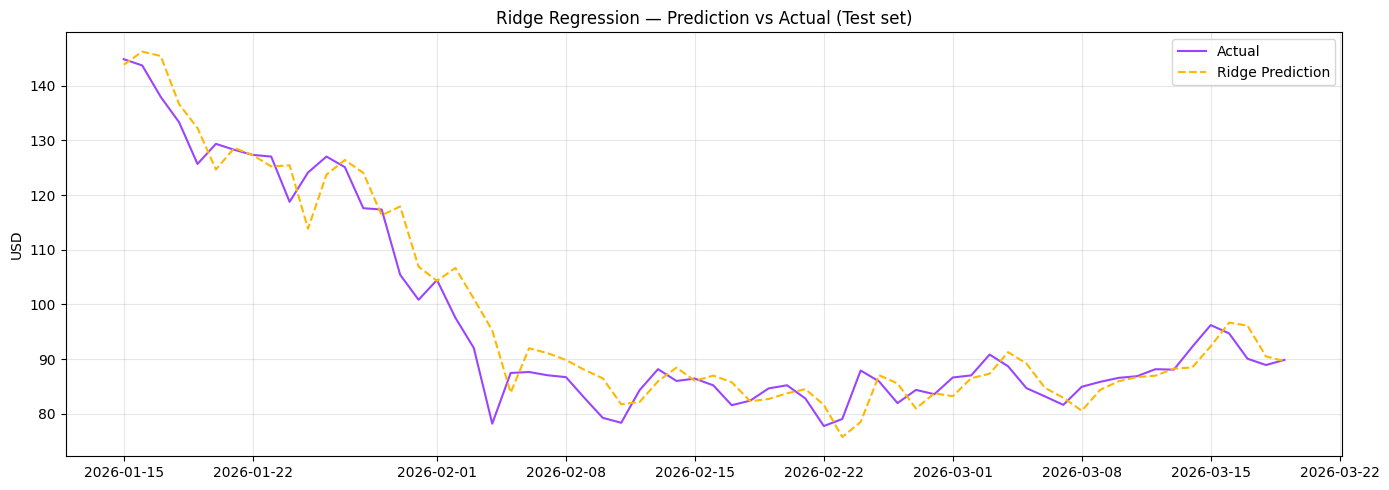

In [7]:
# Visualize predictions on test set (reconstructed prices)
plt.figure(figsize=(14, 5))
plt.plot(dates_test, real_price_test, label='Actual', color='#9945FF', linewidth=1.5)
plt.plot(dates_test, pred_lr_price_test, label='Ridge Prediction', color='#FFB800', linewidth=1.5, linestyle='--')
plt.title('Ridge Regression — Prediction vs Actual (Test set)')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, '04_ridge_prediction.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4.6 Model 2: XGBoost

Gradient Boosting based on decision trees. Widely used in data competitions and finance for its ability to capture non-linear relationships.

In [7]:
xgb_model = xgb.XGBRegressor(                                                                          
    n_estimators=500,                                                                                  
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=30,
    eval_metric='rmse',
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'Best iteration (early stopping): {xgb_model.best_iteration}')

Best iteration (early stopping): 2


In [8]:
pred_xgb_val  = xgb_model.predict(X_val)
pred_xgb_test = xgb_model.predict(X_test)

# Reconstruct prices from predicted returns
pred_xgb_price_val  = close_val  * (1 + pred_xgb_val  / 100)
pred_xgb_price_test = close_test * (1 + pred_xgb_test / 100)

res_xgb_val  = evaluate_model('XGBoost (Validation)', real_price_val, pred_xgb_price_val)
res_xgb_test = evaluate_model('XGBoost (Test)', real_price_test, pred_xgb_price_test)
results.append(res_xgb_test)


 **XGBoost (Validation)**
  MAE  = $3.07   (average absolute error)
  RMSE = $4.00  (penalizes large errors)
  MAPE = 2.29%  (average percentage error)
  R²   = 0.6473    (1.0 = perfect)

 **XGBoost (Test)**
  MAE  = $3.24   (average absolute error)
  RMSE = $4.34  (penalizes large errors)
  MAPE = 3.40%  (average percentage error)
  R²   = 0.9461    (1.0 = perfect)


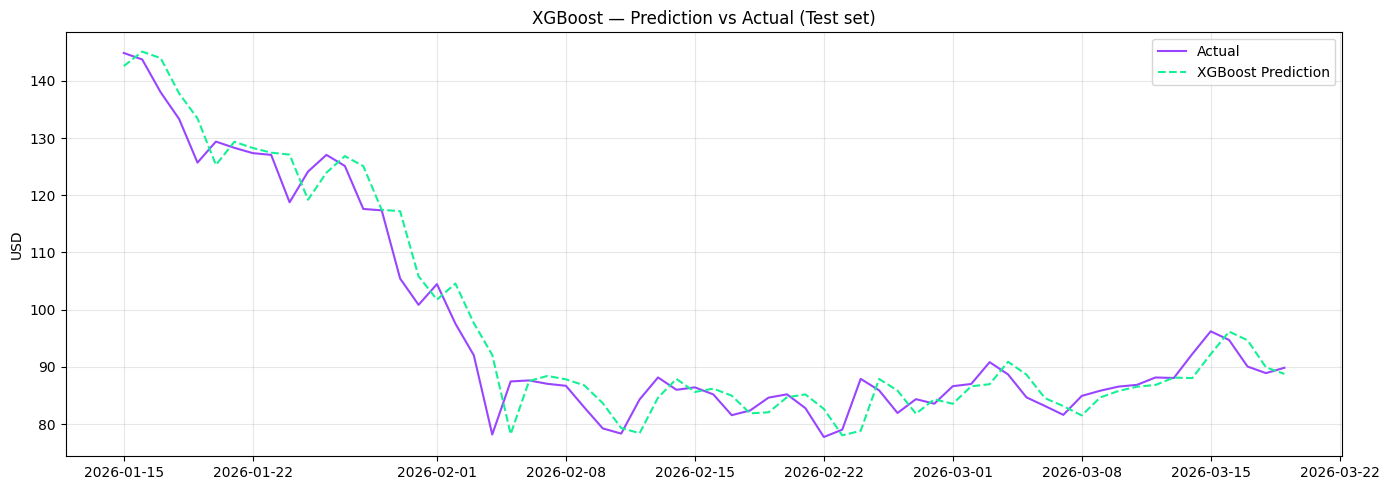

In [9]:
# Visualize predictions on test set (reconstructed prices)
plt.figure(figsize=(14, 5))
plt.plot(dates_test, real_price_test, label='Actual', color='#9945FF', linewidth=1.5)
plt.plot(dates_test, pred_xgb_price_test, label='XGBoost Prediction', color='#14F195', linewidth=1.5, linestyle='--')
plt.title('XGBoost — Prediction vs Actual (Test set)')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, '04_xgboost_prediction.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4.7 Feature Importance (XGBoost)

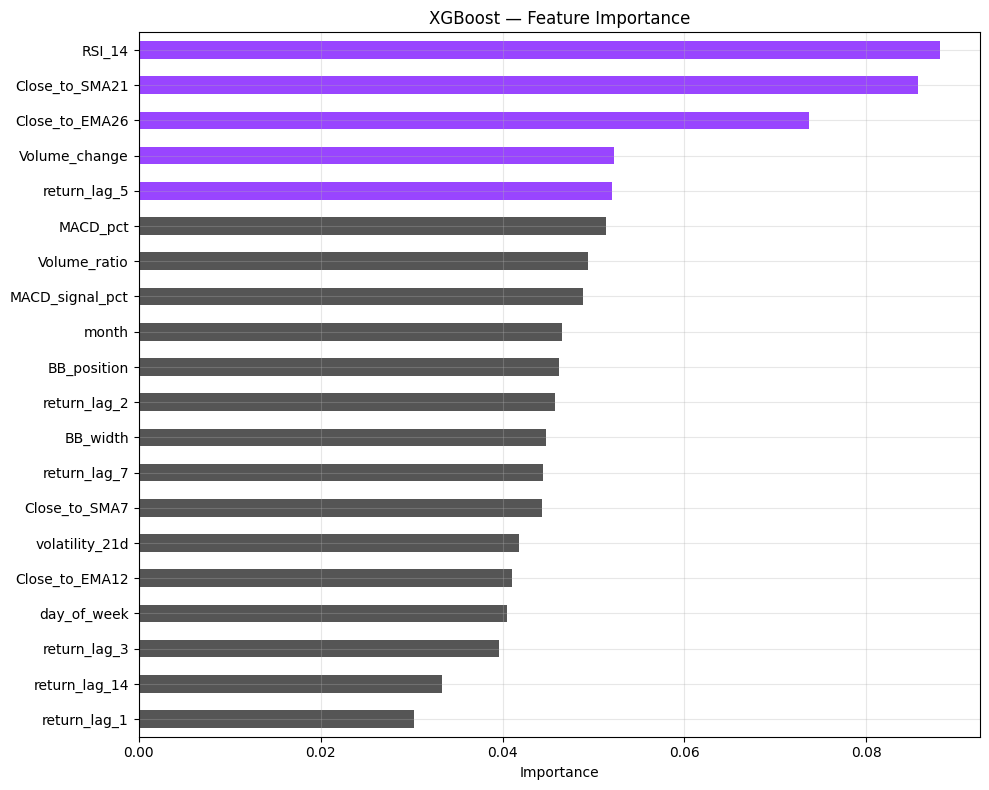


Top 5 most important features:
RSI_14            0.088076
Close_to_SMA21    0.085682
Close_to_EMA26    0.073633
Volume_change     0.052293
return_lag_5      0.052068
dtype: float32


In [10]:
importance = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#9945FF' if i >= len(importance) - 5 else '#555' for i in range(len(importance))]
importance.plot(kind='barh', color=colors)
plt.title('XGBoost — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, '04_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(importance.tail(5).sort_values(ascending=False))

## 4.8 Final Model Comparison


===== MODEL COMPARISON (Test Set) =====
                            MAE    RMSE    MAPE      R2
model                                                  
Ridge Regression (Test)  3.5595  4.8112  3.7627  0.9339
XGBoost (Test)           3.2431  4.3424  3.4037  0.9461


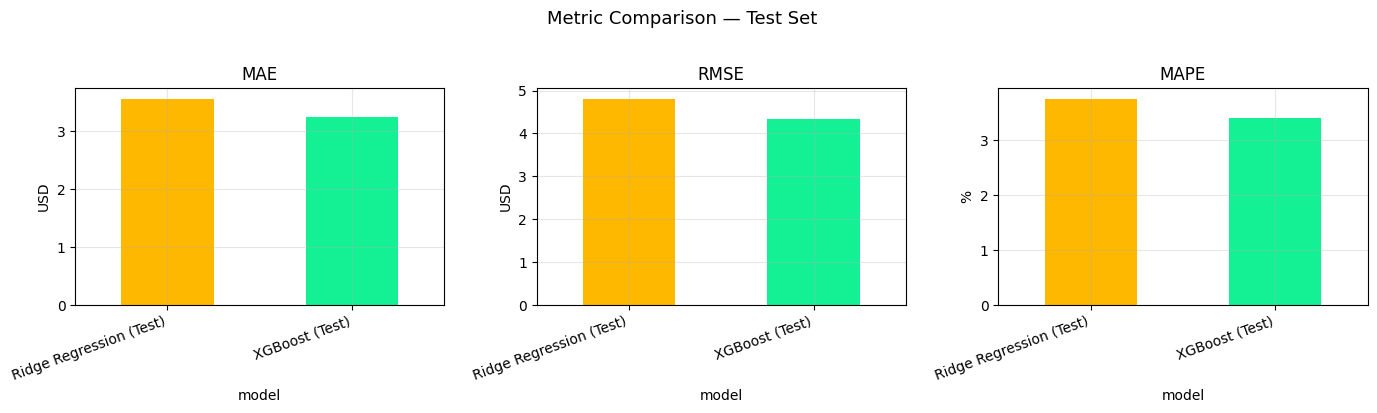

In [11]:
df_results = pd.DataFrame(results)
df_results.set_index('model', inplace=True)
print('\n===== MODEL COMPARISON (Test Set) =====')
print(df_results.round(4).to_string())

# Comparison chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    df_results[metric].plot(kind='bar', ax=ax, color=['#FFB800', '#14F195'], edgecolor='none')
    ax.set_title(metric)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    ax.set_ylabel('USD' if metric != 'MAPE' else '%')

plt.suptitle('Metric Comparison — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, '04_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

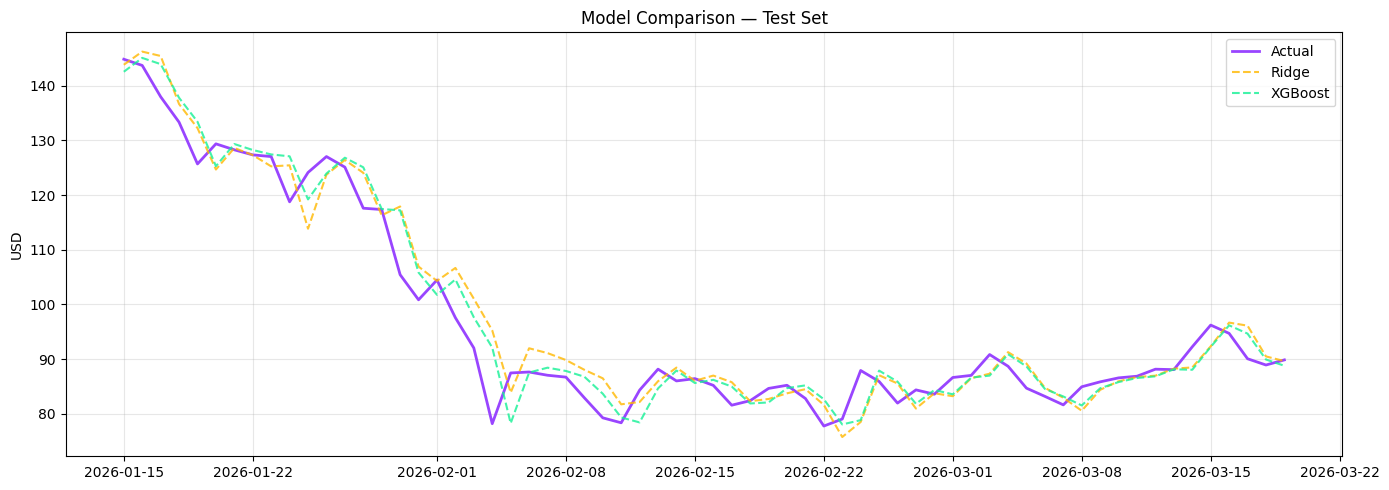

In [13]:
# Side-by-side predictions on test set (reconstructed prices)
plt.figure(figsize=(14, 5))
plt.plot(dates_test, real_price_test,      label='Actual',  color='#9945FF', linewidth=2)
plt.plot(dates_test, pred_lr_price_test,   label='Ridge',   color='#FFB800', linewidth=1.5, linestyle='--', alpha=0.8)
plt.plot(dates_test, pred_xgb_price_test,  label='XGBoost', color='#14F195', linewidth=1.5, linestyle='--', alpha=0.8)
plt.title('Model Comparison — Test Set')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RAW_DIR, '04_prediction_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4.9 Save Models and Predictions

In [12]:
import pickle

# Save models
with open(os.path.join(PROCESSED_DIR, 'ridge_model.pkl'), 'wb') as f:
    pickle.dump(lr, f)
with open(os.path.join(PROCESSED_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
xgb_model.save_model(os.path.join(PROCESSED_DIR, 'xgboost_model.json'))

# Save predictions (reconstructed prices) for the evaluation notebook
df_preds = pd.DataFrame({
    'date': dates_test,
    'real': real_price_test,
    'pred_ridge': pred_lr_price_test,
    'pred_xgb': pred_xgb_price_test
}).set_index('date')
df_preds.to_csv(os.path.join(PROCESSED_DIR, 'predicciones_test.csv'))

print('Models and predictions saved')

Models and predictions saved


---
## ✅ Modeling Summary

| Model | MAE | RMSE | MAPE | R² |
|---|---|---|---|---|
| Ridge Regression | *see output* | *see output* | *see output* | *see output* |
| XGBoost | *see output* | *see output* | *see output* | *see output* |

**Next step →** `05_evaluation.ipynb`